This notebook demonstrates the capabilities of the raytracer in computing attenuation and phase shifts, and uses this to create synthetic diffraction patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(enable_x64 = True)

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag
import processing.plotting as plots
import shared.domains as domains

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: C:\Users\qinal\OneDrive - Imperial College London\UROP\synthPy\src

Disabling python multi-threading...
Initialising jax...


Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19)]


<module 'processing.diagnostics' from 'C:\\Users\\qinal\\OneDrive - Imperial College London\\UROP\\synthPy\\src\\processing\\diagnostics.py'>

First initialise some paramaters which we will use when creating domains and beams.


In [2]:
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3
lengths = 2 * np.array([extent_x, extent_y, extent_z])
probing_extent = extent_z
probing_direction = 'z'

divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

Define the domain. Most variables are part of the domain class and should be initialised below. Mass density and temperature fields are externally loaded.

In [ ]:
n_cells = 128

rho1 = domains.density_step(2e3, 1e3, lengths, n_cells)
Te = np.full((n_cells, n_cells, n_cells), 2e3)


domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=False, ne_0 = 1e27, Ly = extent_y*0.5, s = 2e-3) # B_on = False by default



Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 2.5352745056152344 GB
 - used  : 13.081123352050781 GB

Est. domain memory limit: 48.0 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


Create the beam and trace through the domain! The solutions are stored within 'rf'. It is an array of shape (6, Np). 
The information stored within it is (x position, azimuthal angle, y position, polar angle, amplitude, phase)

In [8]:
lwl = 0.1e-9 #define laser wavelength
Np = 100000    # number of photons

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)
# defaults: return_E = False, parallelise = True, jitted = True, save_points_per_region = 2, memory_debug = False, lwl = 1064e-9, keep_domain = False, return_raw_results = False


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 80.108642578125 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0 seconds
Completed ray trace in 28.647 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (100000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the fo

For this first example, the phase shift has been turned off, and a step function has been imposed for the mass density. As one would expect, a plane wave is seen at the output with two regions clearly attenuated by different amounts.

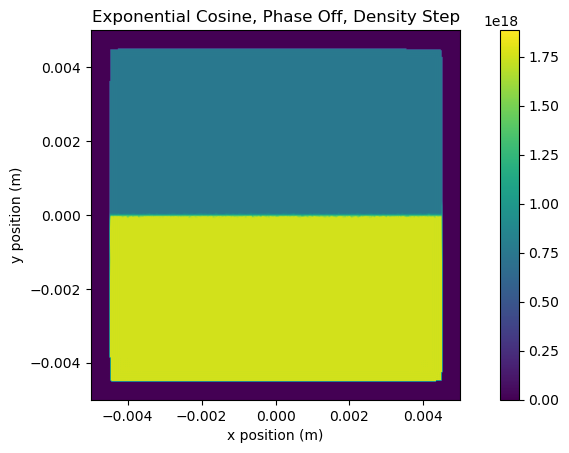

In [12]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 400, 400, "Exponential Cosine, Phase Off, Density Step", 0.1e-9)

Now we trace through with phase shift on, allowing us to observe a diffraction pattern!

In [3]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
n_cells = 128

rho1 = np.full((n_cells, n_cells, n_cells), 1e3)
Te = np.full((n_cells, n_cells, n_cells), 2e3)


domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=True, ne_0 = 1e27, Ly = extent_y*0.5, s = 2e-3) # B_on = False by default


Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 3.3419036865234375 GB
 - used  : 12.274494171142578 GB

Est. domain memory limit: 48.0 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


In [4]:
lwl = 0.1e-9 #define laser wavelength
Np = 100000    # number of photons

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)
# defaults: return_E = False, parallelise = True, jitted = True, save_points_per_region = 2, memory_debug = False, lwl = 1064e-9, keep_domain = False, return_raw_results = False


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 80.108642578125 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0010123252868652344 seconds
Completed ray trace in 34.051 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (100000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and tra

Text(0, 0.5, 'y position')

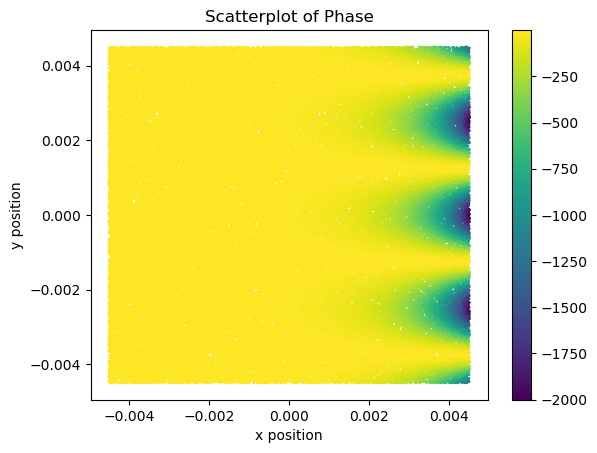

In [ ]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()
plt.title("Scatterplot of Phase")
plt.xlabel("x position")
plt.ylabel("y position")

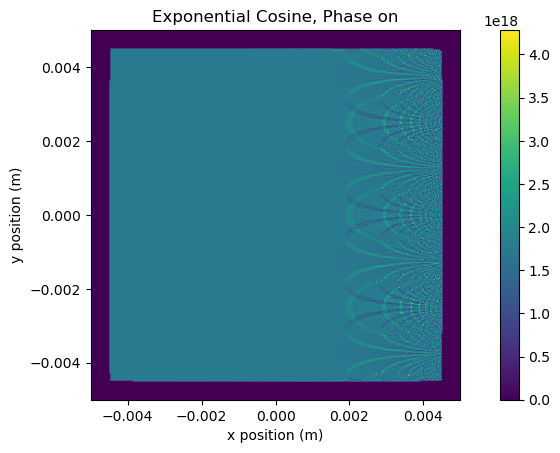

In [48]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 400, 400, "Exponential Cosine, Phase on", 0.1e-9)

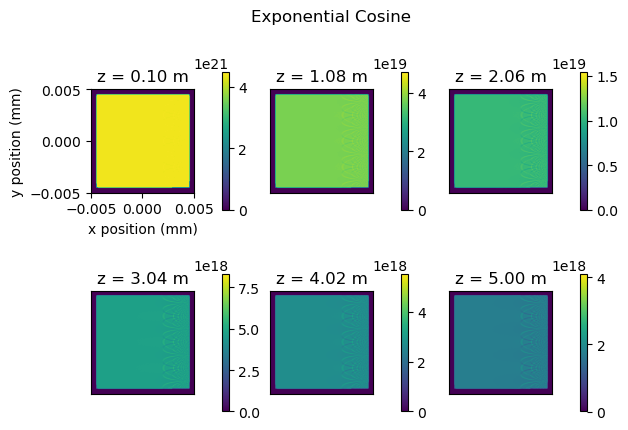

In [6]:
z = np.linspace(0.1,5, 6)
plots.var_distance(domain, rf[0], rf[2], z, rf[5], rf[4], 400, 400, "Exponential Cosine", 0.1e-9)

Now we try a Gaussian turbulent box wih a Kolmogorov spectrum.

In [7]:
n_cells = 128
ne = domains.turbulent_box(2e28, 2.5e28, 3, 2, 5, n_cells)
rho1 = np.full((n_cells, n_cells, n_cells), 1e3)
Te = np.full((n_cells, n_cells, n_cells), 2e3)

domain = d.ScalarDomain(lengths, n_cells, probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=True, ne = ne) # B_on = False by default

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 3.077045440673828 GB
 - used  : 12.539352416992188 GB

Est. domain memory limit: 48.0 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


In [8]:
lwl = 0.1e-9 #define laser wavelength
Np = 100000    # number of photons


beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type)
rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 80.108642578125 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0 seconds
Completed ray trace in 43.396 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (100000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the fo

Text(0, 0.5, 'y position')

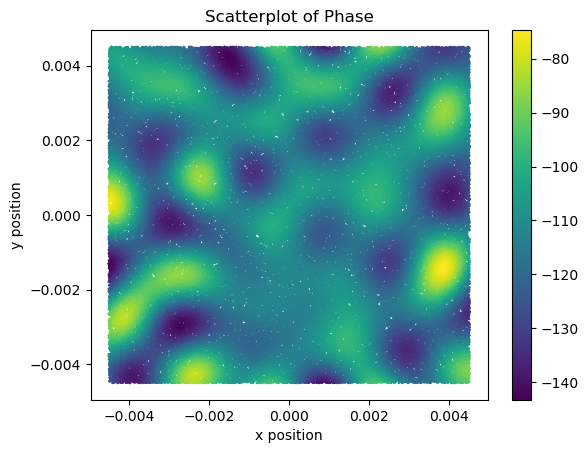

In [14]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()
plt.title("Scatterplot of Phase")
plt.xlabel("x position")
plt.ylabel("y position")


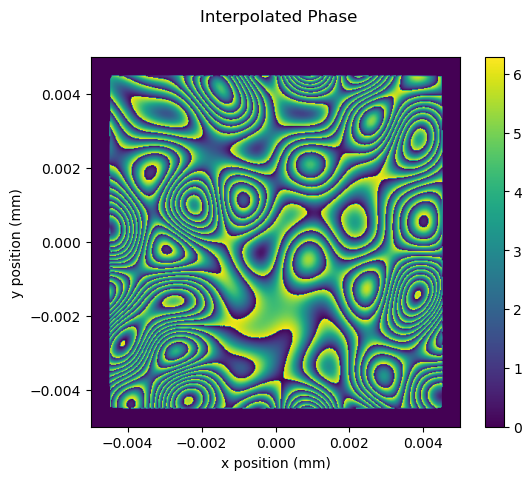

In [37]:
plots.interpolated_phase(domain, rf[0], rf[2], rf[5], 500, 500, wrapped = True)

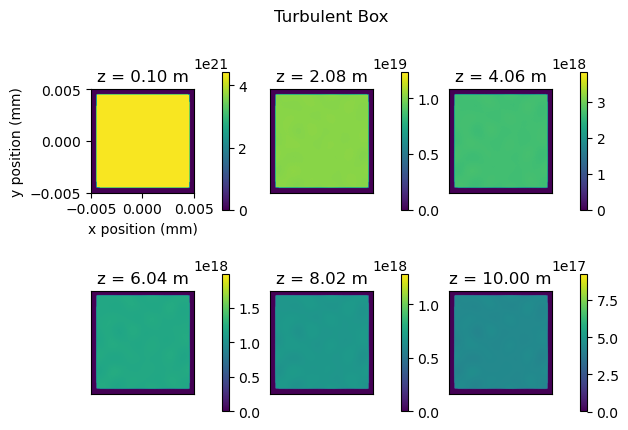

In [10]:
z = np.linspace(0.1,10, 6)
plots.var_distance(domain, rf[0], rf[2], z, rf[5], rf[4], 400, 400, "Turbulent Box", 0.1e-9, pad_factor = 2)

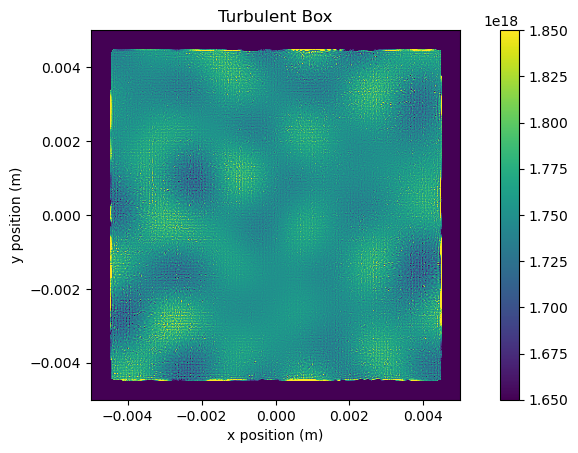

In [9]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 400, 400, "Turbulent Box", 0.1e-9, vmin = 1.65e18, vmax = 1.85e18)

The final example is a sphere with three concentric layers. 

In [15]:
#radii, electron density, mass density should be passed as tuples containing the values in each layer. Here we have a sphere with three layers, 
#so the tuple has length three.

#NB: to clearly see the discontinuity in electron density, a higher domain size helps. ~200 allows for a clear visualisation. 
# As such I haved used less rays when testing; here I have used 50000.
radii = (2e-3, 3e-3,4e-3)
e_densities = (1e27, 1e28, 6e28)
m_densities = (0.3, 3.5e3, 3.5e3)
n_cells = 200
Te = np.full((n_cells, n_cells, n_cells), 2e3)
opacity_files = ("opa_DT_NLTE_Full_linear1000.spk", "opa_C_NLTE_Full_linear1000.spk", "opa_CH_NLTE_Full_linear1000.spk")
ne, densities = domains.spherical(radii, e_densities, m_densities, lengths, n_cells)
domain = d.ScalarDomain(lengths, n_cells, probing_direction = probing_direction, 
                        opacity = True, num_materials=3, densities = densities, Te = Te, 
                        opacity_files=opacity_files, phaseshift=True, ne = ne) 


Predicted size in memory of domain: 30.517578125 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 2.1108436584472656 GB
 - used  : 13.50555419921875 GB

Est. domain memory limit: 183.10546875 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (200, 200, 200) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


In [16]:
lwl = 0.1e-9 #define laser wavelength

# initialise beam
Np = 50000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type)
rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 40.0543212890625 MB
 --> Np = 50000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0 seconds
Completed ray trace in 160.071 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (50000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the fo

Text(0, 0.5, 'y position')

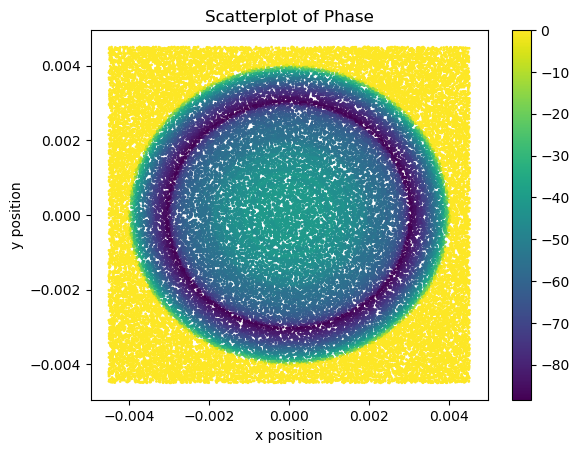

In [17]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()
plt.title("Scatterplot of Phase")
plt.xlabel("x position")
plt.ylabel("y position")

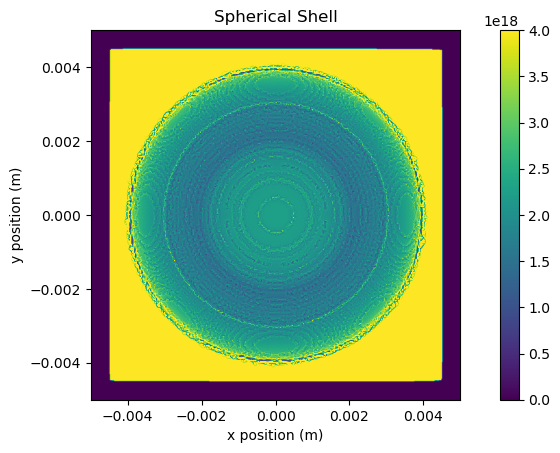

<Figure size 640x480 with 0 Axes>

In [ ]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 800, 800, "Spherical Shell", 0.1e-9, vmax = 4e18)

We also trace through the sphere with phase shift off to better compare absorption spectroscopy with RER.

In [20]:
domain1 = d.ScalarDomain(lengths, n_cells, probing_direction = probing_direction, 
                        opacity = True, num_materials=3, densities = densities, Te = Te, 
                        opacity_files=opacity_files, phaseshift=False, ne = ne) 

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type)
rf_phase_off, _, duration = p.solve(beam_definition.s0, domain1, probing_extent, lwl = lwl)

Predicted size in memory of domain: 30.517578125 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 4.974388122558594 GB
 - used  : 10.642009735107422 GB

Est. domain memory limit: 122.0703125 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (200, 200, 200) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.

Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 40.0543212890625 MB
 --> Np = 50000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0 seconds
Completed ray trace in 148.476 seconds.

Parallelised outpu

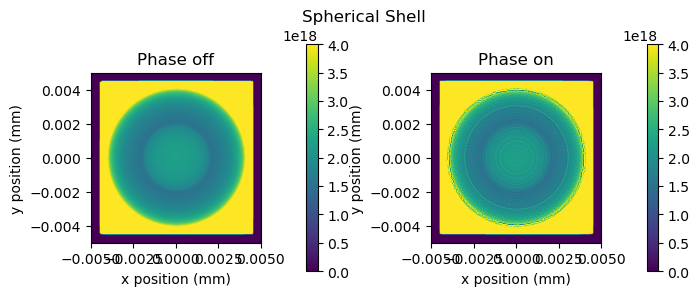

In [ ]:
params = [(rf[0],rf[2], rf[4], rf[5]), (rf_phase_off[0],rf_phase_off[2], rf_phase_off[4], rf_phase_off[5])]
plots.phase_on_off(params, "Spherical Shell", 0.1e-9, domain, 5, vmax = 4e18, vmax1 = 4e18, pix_x=800, pix_y=800)